The Analysis I want to do here is to see if there are tax lots that have a higher population than tax sleds within the view threshold of my walk. If there are, I'd like to then incorporate them into my walk so that I could have seen a higher percentage of people.

In [78]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import osmnx as ox
from shapely.geometry import LineString, Point
from shapely.validation import make_valid

WORKING_CRS = 4326
BUFFER_CRS  = 2263

In [79]:
pluto = gpd.read_file(
    "../Assignments/outputs/population_by_taxlot_bedstuy.geojson"
).to_crs(BUFFER_CRS)

path = gpd.read_file(
    "../Pathmapping_Tool/Data/Walkpath.geojson"
).to_crs(BUFFER_CRS)

print(path.geom_type.value_counts())
print(f"{len(path)} feature(s)")
print(f"Total path length: {path.geometry.length.sum():.0f} ft")

MultiLineString    2
Name: count, dtype: int64
2 feature(s)
Total path length: 33814 ft


To get an understanding of where there might be points of a higher population the way I went about it was by cutting up the line segment into a series of points at every 300 feet and from those 300 feet I will then see if there are tech sleds that have a higher population point. This captures the analysis over the span of the line to see from the whole path as a whole where are the places that have the highest population clusters?

In [80]:
INTERVAL_FT = 300

sample_points = []

for _, path_row in path.iterrows():
    for line in path_row.geometry.geoms:
        length = line.length
        distances = np.arange(0, length, INTERVAL_FT)
        for d in distances:
            pt = line.interpolate(d)
            sample_points.append(pt)

points_gdf = gpd.GeoDataFrame(geometry=sample_points, crs=BUFFER_CRS)

print(f"{len(points_gdf)} sample points generated")

114 sample points generated


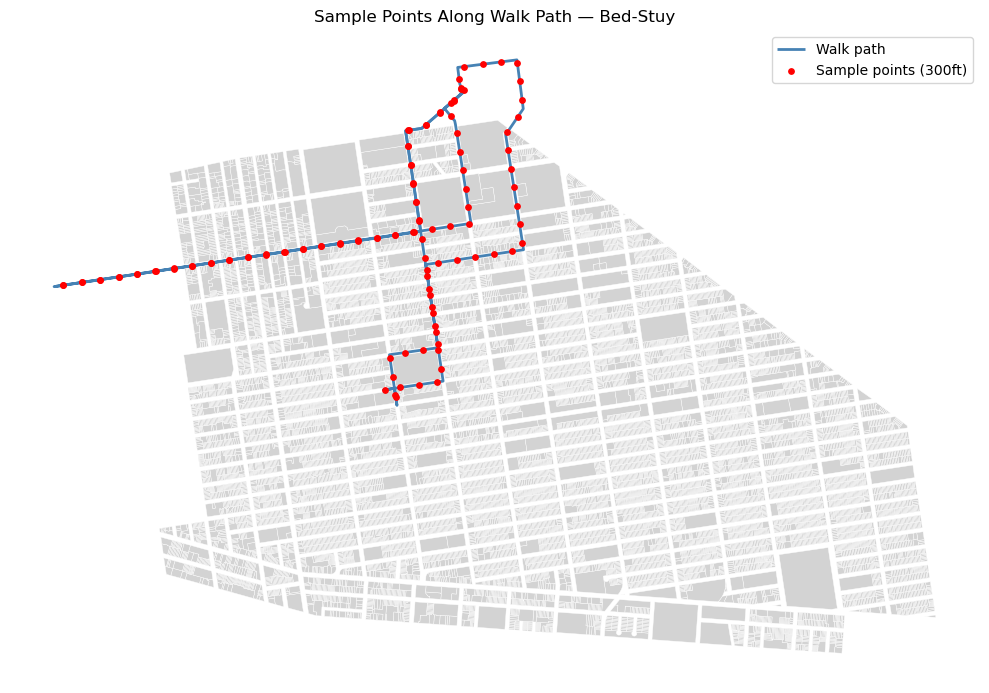

In [81]:
fig, ax = plt.subplots(figsize=(10, 10))

pluto.to_crs(WORKING_CRS).plot(
    ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
)
path.to_crs(WORKING_CRS).plot(
    ax=ax, color="steelblue", linewidth=2, label="Walk path"
)
points_gdf.to_crs(WORKING_CRS).plot(
    ax=ax, color="red", markersize=15, zorder=5, label="Sample points (300ft)"
)

ax.set_title("Sample Points Along Walk Path — Bed-Stuy", fontsize=12)
ax.axis("off")
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig("outputs/sample_points.png", dpi=150, bbox_inches="tight")

Something I did have to do is make sure that I am not calculating points that are already within the walk path I took. When I first did this analysis I noticed that because I was only analyzing based off of if there is a higher population center per point and not incorporating the whole network where instances where a point might be. I got around this by making a inner buffer and any of the analysis for these higher population areas had to occur outside of that inner buffer.

In [82]:
from shapely.ops import unary_union

# Total seen zone across the entire walk
total_seen = unary_union([pt.buffer(INNER_FT) for pt in points_gdf.geometry])

# Lots never seen anywhere along the walk
unseen_lots = pluto[~pluto.geometry.intersects(total_seen)].copy()

print(f"Total lots in Bed-Stuy   : {len(pluto)}")
print(f"Lots within field of view: {len(pluto) - len(unseen_lots)}")
print(f"Lots never seen          : {len(unseen_lots)}")

records = []

for idx, pt_row in points_gdf.iterrows():
    pt_geom    = pt_row.geometry
    inner_buf  = pt_geom.buffer(INNER_FT)
    outer_ring = pt_geom.buffer(OUTER_FT).difference(total_seen)

    inner_lots = pluto[pluto.geometry.intersects(inner_buf)]
    outer_lots = unseen_lots[unseen_lots.geometry.intersects(outer_ring)]

    inner_max = inner_lots["est_pop_per_lot"].max() if len(inner_lots) else 0
    outer_max = outer_lots["est_pop_per_lot"].max() if len(outer_lots) else 0

    outer_target = (
        outer_lots.loc[outer_lots["est_pop_per_lot"].idxmax()]
        if len(outer_lots) else None
    )

    records.append({
        "point_idx":     idx,
        "point_geom":    pt_geom,
        "inner_max_pop": inner_max,
        "outer_max_pop": outer_max,
        "missed":        outer_max > inner_max,
        "target_geom":   outer_target.geometry.centroid if outer_target is not None else None,
    })

results_df = pd.DataFrame(records)

print(f"\nTotal sample points : {len(results_df)}")
print(f"Missed opportunities: {results_df['missed'].sum()}")
print(f"Already optimal     : {(~results_df['missed']).sum()}")

Total lots in Bed-Stuy   : 16597
Lots within field of view: 1152
Lots never seen          : 15445

Total sample points : 114
Missed opportunities: 70
Already optimal     : 44


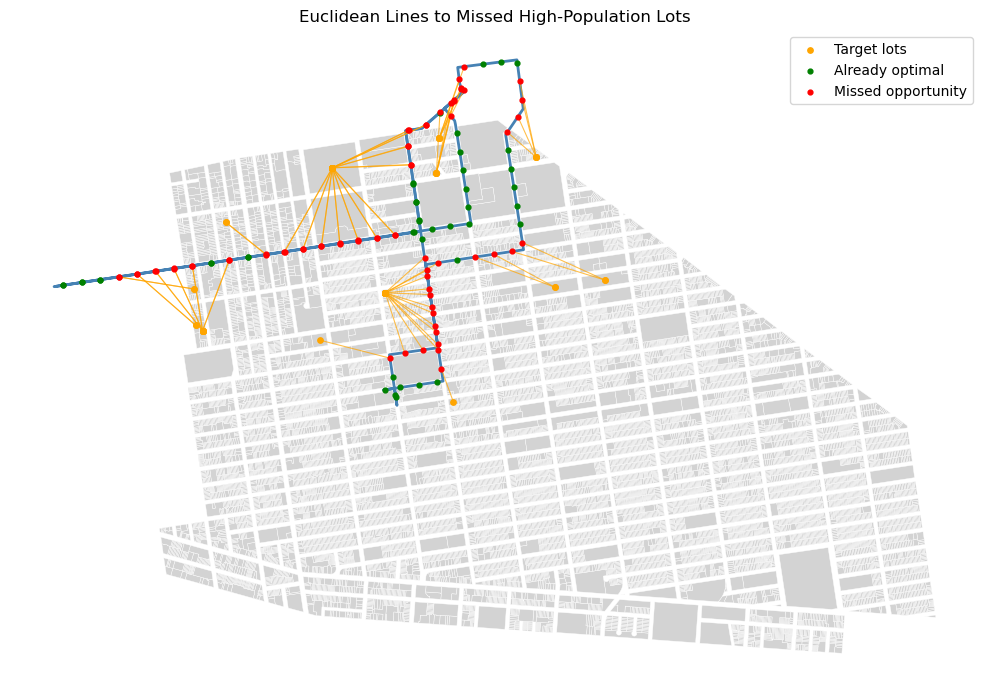

In [83]:
from shapely.geometry import LineString

fig, ax = plt.subplots(figsize=(10, 10))

pluto.to_crs(WORKING_CRS).plot(
    ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
)
path.to_crs(WORKING_CRS).plot(ax=ax, color="steelblue", linewidth=2)

# Draw Euclidean lines from missed points to their targets
for _, row in results_df[results_df["missed"]].iterrows():
    if row["target_geom"] is not None:
        line = gpd.GeoSeries(
            [LineString([row["point_geom"], row["target_geom"]])], crs=BUFFER_CRS
        ).to_crs(WORKING_CRS)
        line.plot(ax=ax, color="orange", linewidth=0.8, alpha=0.7)

# Missed opportunity targets
missed_targets = results_df[results_df["missed"] & results_df["target_geom"].notna()]
gpd.GeoDataFrame(
    geometry=[r["target_geom"] for _, r in missed_targets.iterrows()], crs=BUFFER_CRS
).to_crs(WORKING_CRS).plot(ax=ax, color="orange", markersize=15, zorder=5, label="Target lots")

# Points
gpd.GeoDataFrame(geometry=results_df[~results_df["missed"]]["point_geom"].values, crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
    ax=ax, color="green", markersize=12, zorder=5, label="Already optimal"
)
gpd.GeoDataFrame(geometry=results_df[results_df["missed"]]["point_geom"].values, crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
    ax=ax, color="red", markersize=12, zorder=5, label="Missed opportunity"
)

ax.set_title("Euclidean Lines to Missed High-Population Lots", fontsize=12)
ax.axis("off")
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig("outputs/missed_euclidean.png", dpi=150, bbox_inches="tight")

In [84]:
missed_df = results_df[results_df["missed"]].copy()
missed_df["pop_gain"] = missed_df["outer_max_pop"] - missed_df["inner_max_pop"]

# Round target coords to deduplicate same-lot targets
missed_df["target_key"] = missed_df["target_geom"].apply(
    lambda g: (round(g.x, 1), round(g.y, 1)) if g is not None else None
)

missed_df = (
    missed_df
    .sort_values("pop_gain", ascending=False)
    .drop_duplicates(subset="target_key")
    .reset_index(drop=True)
)

print("Top 10 unique missed opportunities:")
print(missed_df[["point_idx", "inner_max_pop", "outer_max_pop", "pop_gain"]].head(10).to_string())

top2 = missed_df.head(2)

Top 10 unique missed opportunities:
   point_idx  inner_max_pop  outer_max_pop     pop_gain
0         57       8.262295    2514.000000  2505.737705
1         37     284.563193     645.130064   360.566871
2         88       0.000000     334.799235   334.799235
3         78       0.000000     292.543021   292.543021
4         36      68.390779     315.584416   247.193636
5         31      32.610169     231.894539   199.284369
6         25      73.841484     254.578005   180.736521
7         17      21.044634     182.934783   161.890148
8         86       0.000000     134.547779   134.547779
9         94     218.879121     279.785567    60.906446


Great now that we've identified where are the places that have high populations relative to the points within we can pick the top 2 as new routes to take in order to capture more people

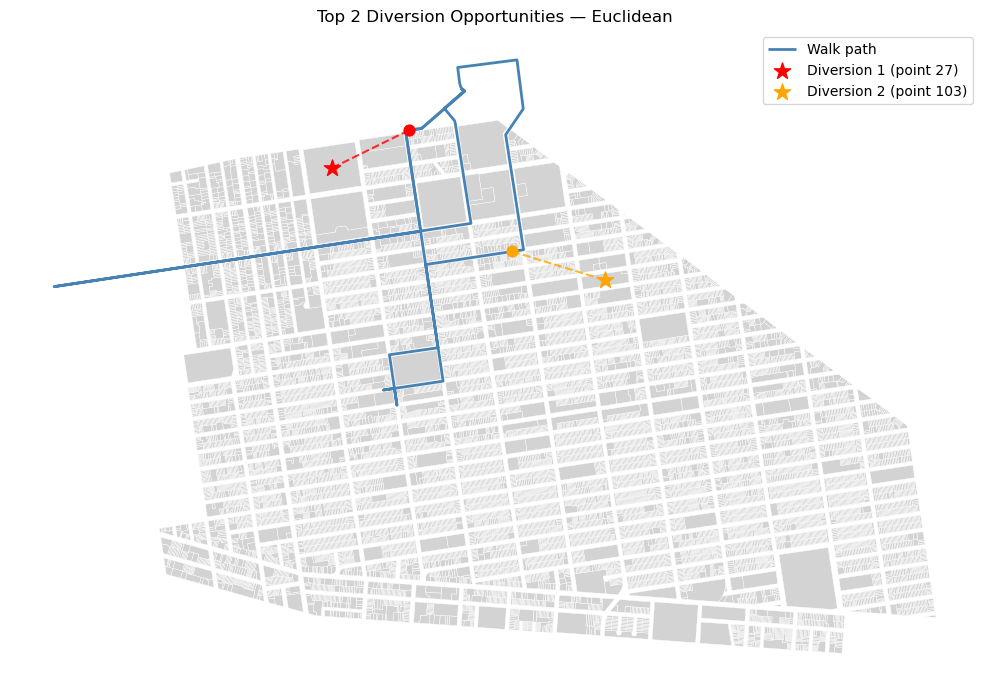

In [85]:
fig, ax = plt.subplots(figsize=(10, 10))

pluto.to_crs(WORKING_CRS).plot(
    ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
)
path.to_crs(WORKING_CRS).plot(ax=ax, color="steelblue", linewidth=2, label="Walk path")

colors = ["red", "orange"]
labels = ["Diversion 1 (point 27)", "Diversion 2 (point 103)"]

for i, (_, row) in enumerate(top2.iterrows()):
    # Euclidean line
    line = gpd.GeoSeries(
        [LineString([row["point_geom"], row["target_geom"]])], crs=BUFFER_CRS
    ).to_crs(WORKING_CRS)
    line.plot(ax=ax, color=colors[i], linewidth=1.5, linestyle="--", alpha=0.8)

    # Origin point
    gpd.GeoDataFrame(
        geometry=[row["point_geom"]], crs=BUFFER_CRS
    ).to_crs(WORKING_CRS).plot(ax=ax, color=colors[i], markersize=60, zorder=5)

    # Target lot
    gpd.GeoDataFrame(
        geometry=[row["target_geom"]], crs=BUFFER_CRS
    ).to_crs(WORKING_CRS).plot(
        ax=ax, color=colors[i], marker="*", markersize=150, zorder=5, label=labels[i]
    )

ax.set_title("Top 2 Diversion Opportunities — Euclidean", fontsize=12)
ax.axis("off")
ax.legend()
plt.tight_layout()
plt.show()

fig.savefig("outputs/top2_euclidean.png", dpi=150, bbox_inches="tight")

In [86]:
import osmnx as ox
import networkx as nx
from shapely.ops import unary_union

WORKING_CRS = 4326
BUFFER_CRS  = 2263

# Rebuild boundary from NTA — same logic as cleaning notebook
nta = gpd.read_file(
    "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/2020_Neighborhood_Tabulation_Areas_(NTAs)_20260717.geojson"
).to_crs(WORKING_CRS)

bedstuy_parts = nta[nta["ntaname"].str.contains("Bedford-Stuyvesant", na=False)]
bedstuy_polygon = unary_union(bedstuy_parts.geometry)

print(f"Boundary type: {bedstuy_polygon.geom_type}")

# Build graph from polygon
G = ox.graph_from_polygon(bedstuy_polygon, network_type="walk")
G = ox.project_graph(G, to_crs=f"EPSG:{BUFFER_CRS}")

print(f"Network: {len(G.nodes)} nodes, {len(G.edges)} edges")

Boundary type: Polygon
Network: 2753 nodes, 8672 edges


In [87]:
network_paths = []

for i, (_, row) in enumerate(top2.iterrows()):
    origin = row["point_geom"]
    target = row["target_geom"]

    # Snap to nearest network nodes
    orig_node = ox.distance.nearest_nodes(G, origin.x, origin.y)
    dest_node = ox.distance.nearest_nodes(G, target.x, target.y)

    # Shortest path
    route = nx.shortest_path(G, orig_node, dest_node, weight="length")
    route_edges = ox.routing.route_to_gdf(G, route)

    network_paths.append({
        "label":        f"Diversion {i+1} (point {row['point_idx']})",
        "color":        ["red", "orange"][i],
        "route_edges":  route_edges,
        "origin":       origin,
        "target":       target,
        "euclid_dist":  origin.distance(target),
        "network_dist": route_edges["length"].sum(),
    })

for p in network_paths:
    ratio = p["network_dist"] / p["euclid_dist"]
    print(f"{p['label']}")
    print(f"  Euclidean : {p['euclid_dist']:.0f} ft")
    print(f"  Network   : {p['network_dist']:.0f} ft")
    print(f"  Circuity  : {ratio:.2f}x")
    print()

Diversion 1 (point 57)
  Euclidean : 1370 ft
  Network   : 665 ft
  Circuity  : 0.49x

Diversion 2 (point 37)
  Euclidean : 1555 ft
  Network   : 573 ft
  Circuity  : 0.37x



In [88]:
METERS_TO_FT = 3.28084

for p in network_paths:
    network_dist_ft = p["network_dist"] * METERS_TO_FT
    ratio = network_dist_ft / p["euclid_dist"]
    print(f"{p['label']}")
    print(f"  Euclidean : {p['euclid_dist']:.0f} ft")
    print(f"  Network   : {network_dist_ft:.0f} ft")
    print(f"  Circuity  : {ratio:.2f}x")
    print()

Diversion 1 (point 57)
  Euclidean : 1370 ft
  Network   : 2180 ft
  Circuity  : 1.59x

Diversion 2 (point 37)
  Euclidean : 1555 ft
  Network   : 1879 ft
  Circuity  : 1.21x



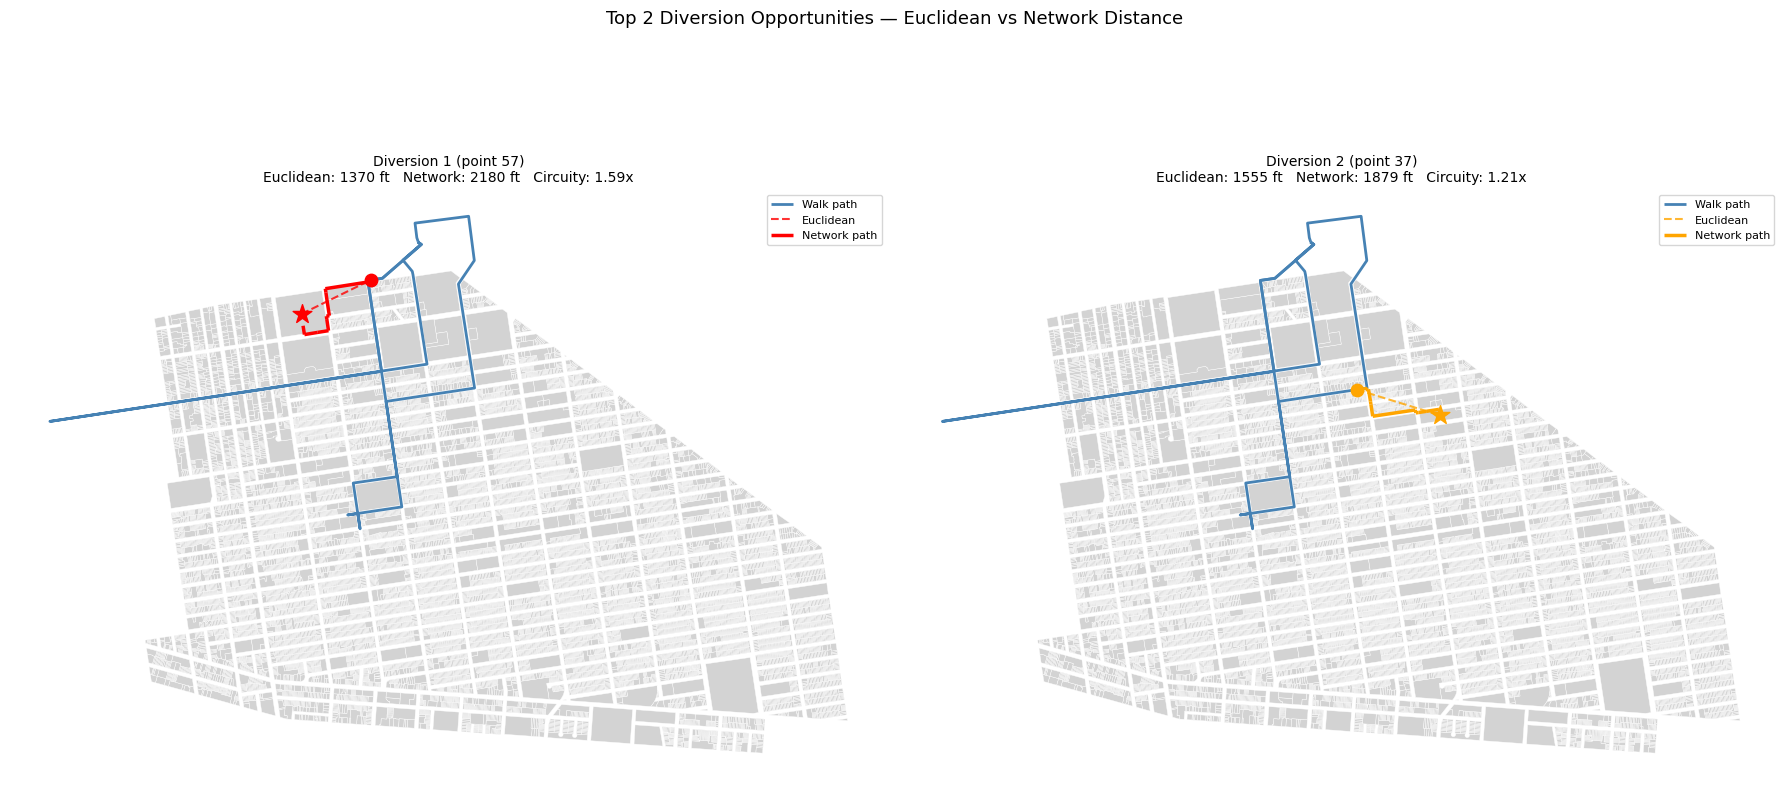

In [89]:
# Update stored distances to feet
for p in network_paths:
    p["network_dist_ft"] = p["network_dist"] * METERS_TO_FT

# Final side-by-side map
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

titles = ["Diversion 1 (point 27)", "Diversion 2 (point 103)"]

for ax, p in zip(axes, network_paths):
    network_dist_ft = p["network_dist_ft"]
    ratio = network_dist_ft / p["euclid_dist"]

    pluto.to_crs(WORKING_CRS).plot(
        ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
    )
    path.to_crs(WORKING_CRS).plot(
        ax=ax, color="steelblue", linewidth=2, label="Walk path"
    )

    # Euclidean line
    euclid_line = gpd.GeoSeries(
        [LineString([p["origin"], p["target"]])], crs=BUFFER_CRS
    ).to_crs(WORKING_CRS)
    euclid_line.plot(
        ax=ax, color=p["color"], linewidth=1.5,
        linestyle="--", alpha=0.8, label="Euclidean"
    )

    # Network path
    p["route_edges"].to_crs(WORKING_CRS).plot(
        ax=ax, color=p["color"], linewidth=2.5, label="Network path"
    )

    # Origin and target
    gpd.GeoDataFrame(geometry=[p["origin"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color=p["color"], markersize=80, zorder=5
    )
    gpd.GeoDataFrame(geometry=[p["target"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color=p["color"], marker="*", markersize=200, zorder=5
    )

    ax.set_title(
        f"{p['label']}\n"
        f"Euclidean: {p['euclid_dist']:.0f} ft   "
        f"Network: {network_dist_ft:.0f} ft   "
        f"Circuity: {ratio:.2f}x",
        fontsize=10
    )
    ax.axis("off")
    ax.legend(fontsize=8)

plt.suptitle(
    "Top 2 Diversion Opportunities — Euclidean vs Network Distance",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

fig.savefig("outputs/top2_network_comparison.png", dpi=150, bbox_inches="tight")

I wanted to add some features to the network path where it was not just going directly to that point but is incorporating it into the broader walk

In [90]:
MIN_ADVANCE_FT = 600  # minimum forward distance before rejoining

detours = []

for i, (_, row) in enumerate(top2.iterrows()):
    origin = row["point_geom"]
    target = row["target_geom"]

    # Find which sub-line the branch point sits on and how far along it
    best_line, best_line_dist = None, None
    best_snap_dist = float("inf")

    for line in merged.geoms:
        d = line.project(origin)
        snapped = line.interpolate(d)
        snap_dist = origin.distance(snapped)
        if snap_dist < best_snap_dist:
            best_snap_dist = snap_dist
            best_line = line
            best_line_dist = d

    # Rejoin point: MIN_ADVANCE_FT ahead on the same sub-line
    rejoin_dist = min(best_line_dist + MIN_ADVANCE_FT, best_line.length)
    rejoin_pt   = best_line.interpolate(rejoin_dist)
    replaced_ft = rejoin_dist - best_line_dist

    # Network: branch → target → rejoin
    orig_node   = ox.distance.nearest_nodes(G, origin.x, origin.y)
    target_node = ox.distance.nearest_nodes(G, target.x, target.y)
    rejoin_node = ox.distance.nearest_nodes(G, rejoin_pt.x, rejoin_pt.y)

    route1  = nx.shortest_path(G, orig_node, target_node, weight="length")
    route2  = nx.shortest_path(G, target_node, rejoin_node, weight="length")
    edges1  = ox.routing.route_to_gdf(G, route1)
    edges2  = ox.routing.route_to_gdf(G, route2)

    detour_ft  = (edges1["length"].sum() + edges2["length"].sum()) * METERS_TO_FT
    net_cost   = detour_ft - replaced_ft

    detours.append({
        "label":       f"Diversion {i+1} (point {row['point_idx']})",
        "color":       ["red", "orange"][i],
        "origin":      origin,
        "target":      target,
        "rejoin_pt":   rejoin_pt,
        "edges1":      edges1,
        "edges2":      edges2,
        "detour_ft":   detour_ft,
        "replaced_ft": replaced_ft,
        "net_cost":    net_cost,
        "pop_gain":    row["pop_gain"],
    })

for d in detours:
    print(f"{d['label']}")
    print(f"  Detour distance  : {d['detour_ft']:.0f} ft")
    print(f"  Replaced segment : {d['replaced_ft']:.0f} ft")
    print(f"  Net extra walking: {d['net_cost']:.0f} ft")
    print(f"  Population gain  : {d['pop_gain']:.0f} people")
    print()

Diversion 1 (point 57)
  Detour distance  : 4361 ft
  Replaced segment : 53 ft
  Net extra walking: 4308 ft
  Population gain  : 2506 people

Diversion 2 (point 37)
  Detour distance  : 4202 ft
  Replaced segment : 600 ft
  Net extra walking: 3602 ft
  Population gain  : 361 people



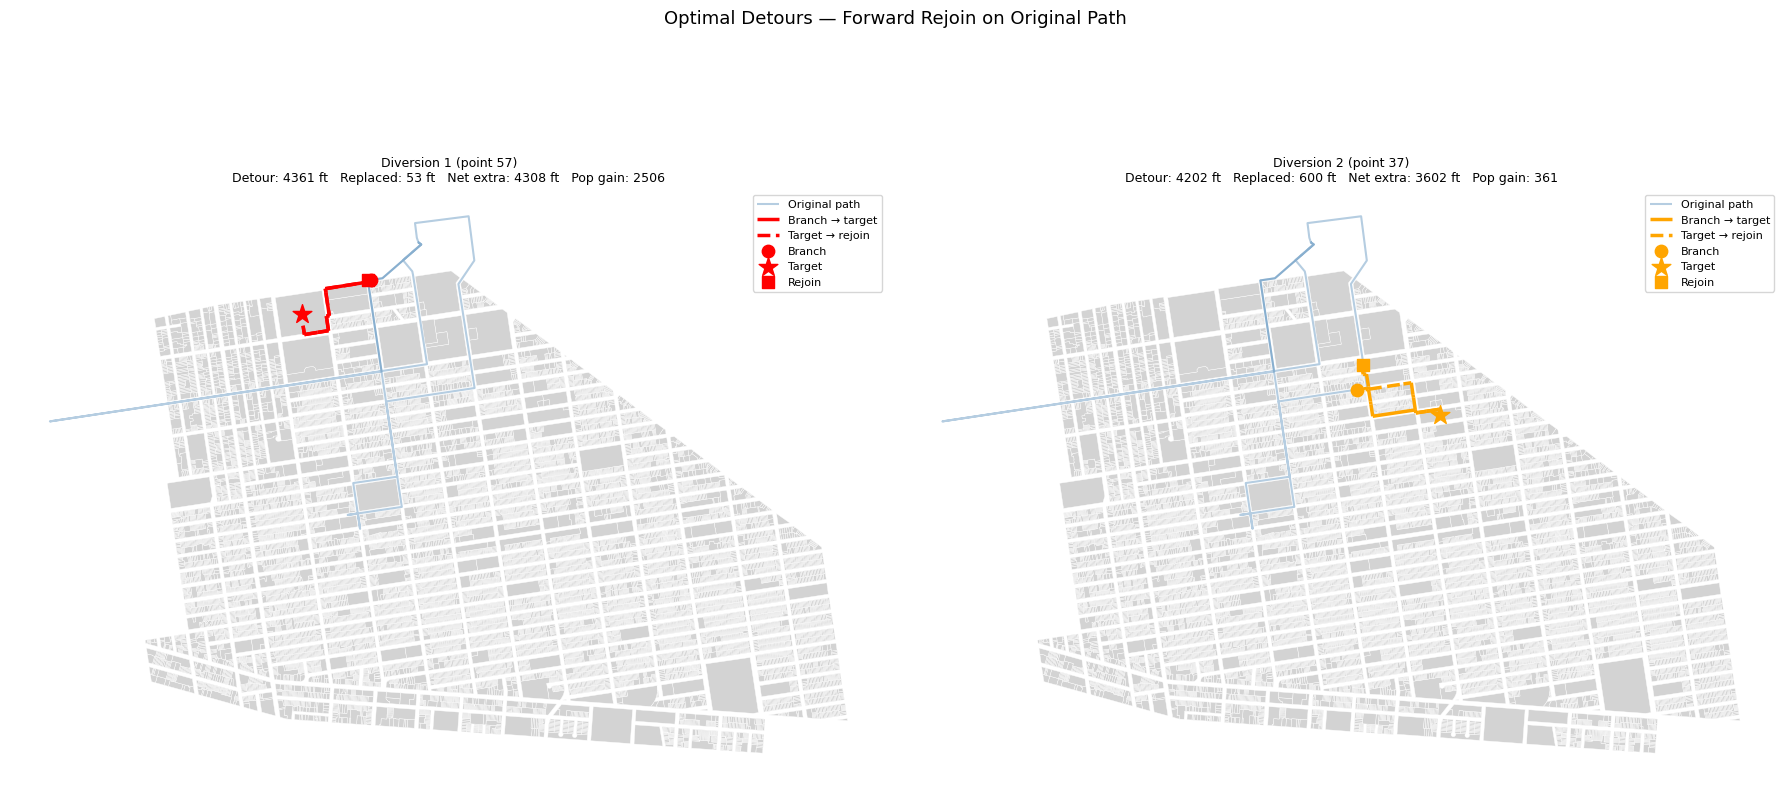

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

for ax, d in zip(axes, detours):

    # Base lots
    pluto.to_crs(WORKING_CRS).plot(
        ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
    )

    # Original path — full in blue
    path.to_crs(WORKING_CRS).plot(
        ax=ax, color="steelblue", linewidth=1.5, alpha=0.4, label="Original path"
    )

    # Detour legs
    d["edges1"].to_crs(WORKING_CRS).plot(
        ax=ax, color=d["color"], linewidth=2.5, label="Branch → target"
    )
    d["edges2"].to_crs(WORKING_CRS).plot(
        ax=ax, color=d["color"], linewidth=2.5, linestyle="dashed", label="Target → rejoin"
    )

    # Branch point
    gpd.GeoDataFrame(geometry=[d["origin"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color=d["color"], markersize=80, zorder=5, label="Branch"
    )
    # Target lot
    gpd.GeoDataFrame(geometry=[d["target"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color=d["color"], marker="*", markersize=200, zorder=5, label="Target"
    )
    # Rejoin point
    gpd.GeoDataFrame(geometry=[d["rejoin_pt"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color=d["color"], marker="s", markersize=80, zorder=5, label="Rejoin"
    )

    ax.set_title(
        f"{d['label']}\n"
        f"Detour: {d['detour_ft']:.0f} ft   "
        f"Replaced: {d['replaced_ft']:.0f} ft   "
        f"Net extra: {d['net_cost']:.0f} ft   "
        f"Pop gain: {d['pop_gain']:.0f}",
        fontsize=9
    )
    ax.axis("off")
    ax.legend(fontsize=8)

plt.suptitle(
    "Optimal Detours — Forward Rejoin on Original Path",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()

fig.savefig("outputs/top2_detours.png", dpi=150, bbox_inches="tight")

One note that I realized with this is because I imported the walk path that I did as a single line rather than a series of lines you have a instance like on the left where that particular street where I am rejoining, I passed over a number of times because it was where I was leaving from my home. To change this would mean changing the Geo Chase on file of the walk past themselves something to think on when building again.